# 04 – Modelling v3 (Validation-Based Hyperparameter Selection)

Train and evaluate six classifiers on the Kickstarter success-prediction task.
All hyperparameter selection is done by evaluating each combination directly on
the held-out **validation set** (`X_val_fit`), rather than using internal
cross-validation. This gives a direct, single-pass estimate of generalisation
and eliminates the dependence on `GridSearchCV` / `TimeSeriesSplit`.

In [1]:
# ── QUICK TEST TOGGLE ─────────────────────────────────────────────────
# Set True for a fast smoke-test (subsample 2000 train + 500 val rows).
# Set False before final submission (full data).
QUICK_TEST = False   # Change to False for full run

In [2]:
import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, roc_curve
)
warnings.filterwarnings('ignore')

OUTPUTS_PATH = 'data'
RANDOM_STATE = 42

In [3]:
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_train.parquet'))
X_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_val.parquet'))
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_test.parquet'))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_train.parquet')).squeeze()
y_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_val.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_test.parquet')).squeeze()

print('X_train:', X_train.shape, '  y_train:', y_train.shape)
print('X_val  :', X_val.shape,   '  y_val  :', y_val.shape)
print('X_test :', X_test.shape,  '  y_test :', y_test.shape)
print('\nClass balance (train):', y_train.value_counts().to_dict())
print('Class balance (val)  :', y_val.value_counts().to_dict())
print('Class balance (test) :', y_test.value_counts().to_dict())

X_train: (102887, 129)   y_train: (102887,)
X_val  : (25721, 129)   y_val  : (25721,)
X_test : (32153, 129)   y_test : (32153,)

Class balance (train): {1: 58566, 0: 44321}
Class balance (val)  : {1: 16762, 0: 8959}
Class balance (test) : {1: 22454, 0: 9699}


In [4]:
if QUICK_TEST:
    N_TRAIN = 2000
    N_VAL   = 500
    rng = np.random.default_rng(RANDOM_STATE)
    idx_tr = rng.choice(len(X_train), size=min(N_TRAIN, len(X_train)), replace=False)
    idx_va = rng.choice(len(X_val),   size=min(N_VAL,   len(X_val)),   replace=False)
    idx_tr = np.sort(idx_tr)   # preserve temporal order
    idx_va = np.sort(idx_va)
    X_train_fit, y_train_fit = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    X_val_fit,   y_val_fit   = X_val.iloc[idx_va],   y_val.iloc[idx_va]
    print(f'QUICK_TEST — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')
else:
    X_train_fit, y_train_fit = X_train, y_train
    X_val_fit,   y_val_fit   = X_val,   y_val
    print(f'Full run — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')

Full run — using 102887 train rows, 25721 val rows


## Primary Metric: ROC-AUC

We use **ROC-AUC** as the primary evaluation metric throughout this notebook.

**Rationale:**
- The dataset has class imbalance (success vs. failure proportions differ by split after temporal cutoff).
- ROC-AUC measures the model's ability to rank positive examples above negative ones across *all* decision thresholds, making it robust to imbalance.
- Unlike accuracy, it does not penalise a model for choosing a sensible operating threshold after training.
- It is interpretable: 0.5 = random, 1.0 = perfect, allowing direct comparison across model families.

All hyperparameter search loops use **validation ROC-AUC** (`val_auc` on `X_val_fit`) as the selection criterion.

## Model Selection Approach

Rather than using `GridSearchCV` with internal cross-validation, this notebook uses
**direct validation-set evaluation** for hyperparameter selection:

1. For each model family, a `ParameterGrid` is constructed listing all combinations.
2. Each combination is trained on `X_train_fit` and scored on `X_val_fit`.
3. The combination with the **highest validation ROC-AUC** is chosen as the best.
4. The best model is then retrained on `X_train_fit` (it was already trained there during the loop).

**Why this is valid:**
`X_val_fit` is a strictly held-out set from a later time period (2023–2024); it was never used to
train any model. Selecting hyperparameters based on validation AUC is equivalent to one round of
hold-out model selection — a well-established and interpretable approach.

**Why this is preferred over GridSearchCV + TimeSeriesSplit here:**
`TimeSeriesSplit` CV on the training set (2014–2023) tests generalisation *within* the training era.
Our actual deployment target is the 2023–2026 window. The validation set is a direct sample from
that target era, so a single validation score is a better proxy for out-of-sample performance than
internal CV on training-era data.

**Trade-off acknowledged:**
Because we use a single validation split rather than multiple CV folds, the hyperparameter selection
has higher variance — a different random validation subsample would yield slightly different winners.
This is accepted as a reasonable trade-off given the temporal alignment benefit.

In [5]:
# Accumulate train + val results for comparison
results = {}

## Model Selection Note: Why KNN is Excluded

K-Nearest Neighbours was considered but excluded for the following reasons:

1. **Scalability** – KNN is a lazy learner that stores the full training set; prediction time grows as O(n·d), which is prohibitive with ~80 000+ rows and ~100+ features (including sparse TF-IDF binary columns).
2. **Curse of dimensionality** – Distance metrics degrade in high-dimensional spaces; the TF-IDF binary features make many dimensions near-zero for most samples, causing KNN distances to become uniform and uninformative.
3. **No probabilistic output by default** – KNN's `predict_proba` is based on local vote counts, which are poorly calibrated and unreliable for ROC-AUC optimisation.
4. **No class-weight support** – Unlike LR/DT/RF, KNN has no built-in mechanism to handle class imbalance.

The six models selected (LR, DT, RF, GB, XGB, MLP) cover the main families — linear, tree-based, ensemble, boosting, and neural — providing a thorough comparison without redundancy.

## Model 1: Logistic Regression (Baseline)

**Justification:** Logistic Regression is our linear baseline. It is fast, interpretable, and well-calibrated. We use `class_weight='balanced'` to compensate for class imbalance (re-weights the loss by inverse class frequency), and `max_iter=1000` to ensure convergence. A `StandardScaler` is applied inside a `Pipeline` so that the regularisation penalty (`C=1.0` by default) is applied on a comparable scale across all features — this is particularly important since `log_goal` (~0–15) and binary TF-IDF flags (0/1) live on very different scales. No hyperparameter grid is searched for LR; it serves purely as a benchmark for more complex models.

In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])
lr_pipe.fit(X_train_fit, y_train_fit)
lr_train_auc = roc_auc_score(y_train_fit, lr_pipe.predict_proba(X_train_fit)[:, 1])
lr_val_auc   = roc_auc_score(y_val_fit,   lr_pipe.predict_proba(X_val_fit)[:, 1])
print(f'=== Logistic Regression — Train ROC-AUC: {lr_train_auc:.4f} | Val ROC-AUC: {lr_val_auc:.4f} ===')
print(classification_report(y_val_fit, lr_pipe.predict(X_val_fit)))
results['Logistic Regression'] = {
    'model'    : lr_pipe,
    'train_auc': lr_train_auc,
    'auc'      : lr_val_auc,
    'y_proba'  : lr_pipe.predict_proba(X_val_fit)[:, 1],
}

=== Logistic Regression — Train ROC-AUC: 0.8779 | Val ROC-AUC: 0.7792 ===
              precision    recall  f1-score   support

           0       0.66      0.55      0.60      8959
           1       0.78      0.85      0.81     16762

    accuracy                           0.75     25721
   macro avg       0.72      0.70      0.71     25721
weighted avg       0.74      0.75      0.74     25721



## Model 2: Decision Tree

**Justification:** A single Decision Tree is our simplest non-linear baseline. It is fully interpretable but prone to memorisation — a tree with no depth or leaf-size constraints will simply partition the training data until it has one sample per leaf, which produces a near-perfect training AUC but terrible generalisation. To prevent this, we deliberately exclude shallow leaf sizes: `min_samples_leaf` starts at 20, forcing every leaf to be supported by at least 20 campaigns. `max_depth` is capped at 10 — deeper than this and a single tree starts interpolating training noise rather than learning patterns. `class_weight='balanced'` handles the class imbalance. We search 3 × 3 = **9 combinations**, selecting the best by validation ROC-AUC.

In [7]:
dt_param_grid = {
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [20, 50, 100],
}
# 3 × 3 = 9 combinations; select best by validation ROC-AUC

dt_loop_results = []
total_dt = len(list(ParameterGrid(dt_param_grid)))
for i, params in enumerate(ParameterGrid(dt_param_grid), 1):
    model = DecisionTreeClassifier(**params, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(X_train_fit, y_train_fit)
    train_auc = roc_auc_score(y_train_fit, model.predict_proba(X_train_fit)[:, 1])
    val_auc   = roc_auc_score(y_val_fit,   model.predict_proba(X_val_fit)[:, 1])
    dt_loop_results.append({**params, 'train_auc': train_auc, 'val_auc': val_auc})
    print(f'  [{i:02d}/{total_dt}] max_depth={params["max_depth"]:>2}  '
          f'min_samples_leaf={params["min_samples_leaf"]:>3}  '
          f'train={train_auc:.4f}  val={val_auc:.4f}')

df_dt = pd.DataFrame(dt_loop_results).sort_values('val_auc', ascending=False).reset_index(drop=True)
print('\n── Decision Tree: all combinations (sorted by val_auc) ──')
print(df_dt.to_string(index=False))

best_dt_params = df_dt.iloc[0].drop(['train_auc', 'val_auc']).to_dict()
best_dt_params = {k: (int(v) if isinstance(v, (float, np.floating)) and v == int(v) else v)
                  for k, v in best_dt_params.items()}
print(f'\nBest DT params (val AUC={df_dt.iloc[0]["val_auc"]:.4f}): {best_dt_params}')

dt_best = DecisionTreeClassifier(**best_dt_params, class_weight='balanced', random_state=RANDOM_STATE)
dt_best.fit(X_train_fit, y_train_fit)
dt_train_auc = roc_auc_score(y_train_fit, dt_best.predict_proba(X_train_fit)[:, 1])
dt_val_auc   = roc_auc_score(y_val_fit,   dt_best.predict_proba(X_val_fit)[:, 1])
print(f'\n=== Decision Tree — Train ROC-AUC: {dt_train_auc:.4f} | Val ROC-AUC: {dt_val_auc:.4f} ===')
print(classification_report(y_val_fit, dt_best.predict(X_val_fit)))
results['Decision Tree'] = {
    'model'    : dt_best,
    'train_auc': dt_train_auc,
    'auc'      : dt_val_auc,
    'y_proba'  : dt_best.predict_proba(X_val_fit)[:, 1],
}
print(f'Train–Val Gap: {dt_train_auc - dt_val_auc:.4f}')

  [01/9] max_depth= 3  min_samples_leaf= 20  train=0.8241  val=0.6967
  [02/9] max_depth= 3  min_samples_leaf= 50  train=0.8241  val=0.6967
  [03/9] max_depth= 3  min_samples_leaf=100  train=0.8241  val=0.6967
  [04/9] max_depth= 5  min_samples_leaf= 20  train=0.8600  val=0.7281
  [05/9] max_depth= 5  min_samples_leaf= 50  train=0.8600  val=0.7282
  [06/9] max_depth= 5  min_samples_leaf=100  train=0.8600  val=0.7282
  [07/9] max_depth=10  min_samples_leaf= 20  train=0.8933  val=0.7453
  [08/9] max_depth=10  min_samples_leaf= 50  train=0.8910  val=0.7471
  [09/9] max_depth=10  min_samples_leaf=100  train=0.8881  val=0.7445

── Decision Tree: all combinations (sorted by val_auc) ──
 max_depth  min_samples_leaf  train_auc  val_auc
        10                50   0.891001 0.747086
        10                20   0.893301 0.745266
        10               100   0.888132 0.744493
         5               100   0.860042 0.728210
         5                50   0.860040 0.728208
         5       

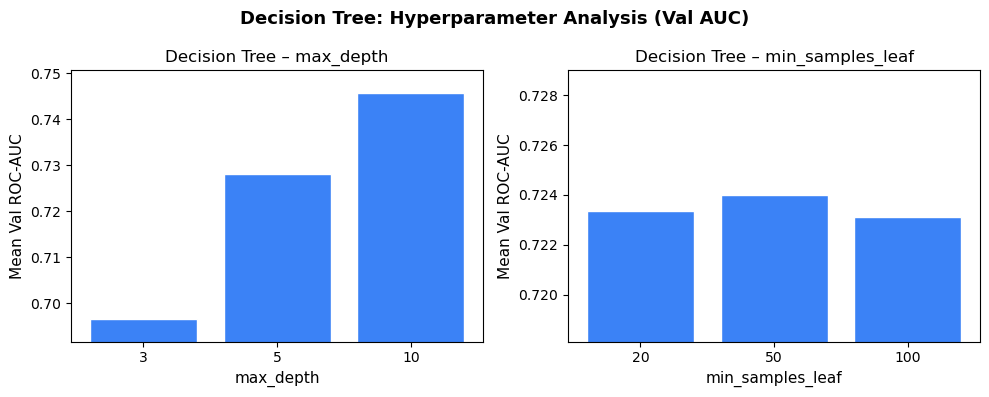

In [8]:
# Parameter analysis – Decision Tree (val_auc by hyperparameter value)
params_to_plot = [c for c in df_dt.columns if c not in ('train_auc', 'val_auc')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = df_dt.groupby(param)['val_auc'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#3B82F6', edgecolor='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Val ROC-AUC', fontsize=11)
    ax.set_ylim(max(0, grouped.values.min() - 0.005), grouped.values.max() + 0.005)
    ax.set_title(f'Decision Tree – {param}', fontsize=12)
plt.suptitle('Decision Tree: Hyperparameter Analysis (Val AUC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** [UPDATE AFTER RUN] — Note whether `max_depth` still shows a strong positive effect, and whether `min_samples_leaf` shows the same or reversed pattern compared to v1. If `min_samples_leaf=20` outperforms `min_samples_leaf=100` here, that suggests moderate leaf regularisation is the sweet spot. If the best configuration is still at the grid boundary (e.g. `max_depth=10`, `min_samples_leaf=20`), check whether the train-val gap is meaningfully smaller than in v1.

## Model 3: Random Forest

**Justification:** Random Forest aggregates many decorrelated trees using bootstrap sampling and random feature subsets (`max_features='sqrt'`), which reduces variance substantially. The v1 grid selected `max_depth=30` and `min_samples_leaf=1`, which produced a train AUC of 0.9998 — effectively memorising the training data. This is a problem because memorised patterns do not transfer to future time periods. In v3 we cap `max_depth` at 20 and raise the minimum leaf size to 5 — this forces the forest to learn population-level patterns instead of individual campaigns. We search 2 × 3 × 1 × 3 = **18 combinations**, selecting the best by validation ROC-AUC.

In [9]:
rf_param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [10, 15, 20],
    'max_features'    : ['sqrt'],
    'min_samples_leaf': [5, 10, 20],
}
# 2 × 3 × 1 × 3 = 18 combinations; select best by validation ROC-AUC

rf_loop_results = []
total_rf = len(list(ParameterGrid(rf_param_grid)))
for i, params in enumerate(ParameterGrid(rf_param_grid), 1):
    model = RandomForestClassifier(**params, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(X_train_fit, y_train_fit)
    train_auc = roc_auc_score(y_train_fit, model.predict_proba(X_train_fit)[:, 1])
    val_auc   = roc_auc_score(y_val_fit,   model.predict_proba(X_val_fit)[:, 1])
    rf_loop_results.append({**params, 'train_auc': train_auc, 'val_auc': val_auc})
    print(f'  [{i:02d}/{total_rf}] n_est={params["n_estimators"]:>3}  '
          f'depth={params["max_depth"]:>2}  '
          f'leaf={params["min_samples_leaf"]:>2}  '
          f'train={train_auc:.4f}  val={val_auc:.4f}')

df_rf = pd.DataFrame(rf_loop_results).sort_values('val_auc', ascending=False).reset_index(drop=True)
print('\n── Random Forest: all combinations (sorted by val_auc) ──')
print(df_rf.to_string(index=False))

best_rf_params = df_rf.iloc[0].drop(['train_auc', 'val_auc']).to_dict()
best_rf_params = {k: (int(v) if isinstance(v, (float, np.floating)) and v == int(v) else v)
                  for k, v in best_rf_params.items()}
print(f'\nBest RF params (val AUC={df_rf.iloc[0]["val_auc"]:.4f}): {best_rf_params}')

rf_best = RandomForestClassifier(**best_rf_params, class_weight='balanced', random_state=RANDOM_STATE)
rf_best.fit(X_train_fit, y_train_fit)
rf_train_auc = roc_auc_score(y_train_fit, rf_best.predict_proba(X_train_fit)[:, 1])
rf_val_auc   = roc_auc_score(y_val_fit,   rf_best.predict_proba(X_val_fit)[:, 1])
print(f'\n=== Random Forest — Train ROC-AUC: {rf_train_auc:.4f} | Val ROC-AUC: {rf_val_auc:.4f} ===')
print(classification_report(y_val_fit, rf_best.predict(X_val_fit)))
results['Random Forest'] = {
    'model'    : rf_best,
    'train_auc': rf_train_auc,
    'auc'      : rf_val_auc,
    'y_proba'  : rf_best.predict_proba(X_val_fit)[:, 1],
}
print(f'Train–Val Gap: {rf_train_auc - rf_val_auc:.4f}')

  [01/18] n_est=200  depth=10  leaf= 5  train=0.8893  val=0.7813
  [02/18] n_est=300  depth=10  leaf= 5  train=0.8898  val=0.7813
  [03/18] n_est=200  depth=10  leaf=10  train=0.8885  val=0.7801
  [04/18] n_est=300  depth=10  leaf=10  train=0.8886  val=0.7802
  [05/18] n_est=200  depth=10  leaf=20  train=0.8873  val=0.7807
  [06/18] n_est=300  depth=10  leaf=20  train=0.8874  val=0.7806
  [07/18] n_est=200  depth=15  leaf= 5  train=0.9099  val=0.7863
  [08/18] n_est=300  depth=15  leaf= 5  train=0.9102  val=0.7859
  [09/18] n_est=200  depth=15  leaf=10  train=0.9047  val=0.7840
  [10/18] n_est=300  depth=15  leaf=10  train=0.9047  val=0.7839
  [11/18] n_est=200  depth=15  leaf=20  train=0.8992  val=0.7838
  [12/18] n_est=300  depth=15  leaf=20  train=0.8991  val=0.7847
  [13/18] n_est=200  depth=20  leaf= 5  train=0.9285  val=0.7866
  [14/18] n_est=300  depth=20  leaf= 5  train=0.9288  val=0.7868
  [15/18] n_est=200  depth=20  leaf=10  train=0.9156  val=0.7847
  [16/18] n_est=300  dept

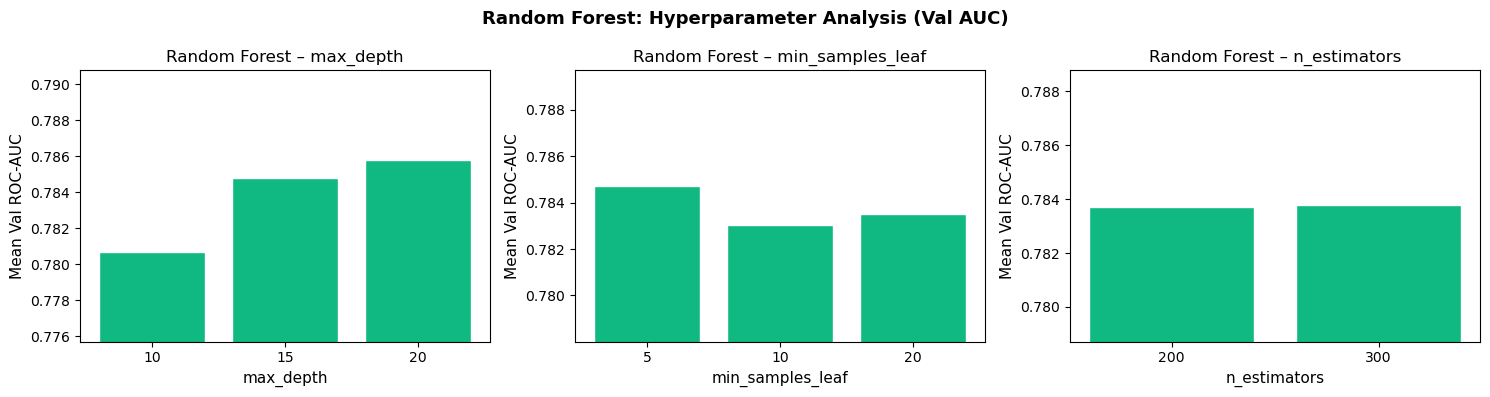

In [10]:
# Parameter analysis – Random Forest (val_auc by hyperparameter value)
params_to_plot = [c for c in df_rf.columns if c not in ('train_auc', 'val_auc', 'max_features')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = df_rf.groupby(param)['val_auc'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#10B981', edgecolor='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Val ROC-AUC', fontsize=11)
    ax.set_ylim(max(0, grouped.values.min() - 0.005), grouped.values.max() + 0.005)
    ax.set_title(f'Random Forest – {param}', fontsize=12)
plt.suptitle('Random Forest: Hyperparameter Analysis (Val AUC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** [UPDATE AFTER RUN] — Key things to look for: (1) Is the train AUC now meaningfully below 0.99, indicating the regularisation worked? (2) Does `min_samples_leaf` show a clear optimum in the 5–20 range, or does the lowest value still win? If the lowest value (5) still wins, try higher values in a follow-up. (3) How does val AUC compare to v1 — a small drop in val AUC is acceptable if the train-val gap has closed significantly, as it means the model is actually generalising rather than memorising.

## Model 4: Gradient Boosting

**Justification:** Gradient Boosting builds trees sequentially, each correcting the residual errors of the previous ensemble. It often achieves a good bias-variance trade-off on tabular data because it focuses capacity on difficult examples rather than easy ones. `class_weight` is **not** supported by sklearn's `GradientBoostingClassifier`, so we rely on `subsample=0.8` (stochastic GB) as regularisation — each tree only sees 80% of training data, which both reduces overfitting and slightly handles imbalance by varying the effective class distribution each round. In v3 we fix `subsample=0.8` (v1 showed it always outperformed 1.0, so there is no need to grid-search it), reducing the search to 2 × 2 × 2 = **8 combinations** selected by validation ROC-AUC.

In [11]:
gb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8],   # fixed — v1 showed this always beats 1.0
}
# 2 × 2 × 2 × 1 = 8 combinations; select best by validation ROC-AUC

gb_loop_results = []
total_gb = len(list(ParameterGrid(gb_param_grid)))
for i, params in enumerate(ParameterGrid(gb_param_grid), 1):
    model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    model.fit(X_train_fit, y_train_fit)
    train_auc = roc_auc_score(y_train_fit, model.predict_proba(X_train_fit)[:, 1])
    val_auc   = roc_auc_score(y_val_fit,   model.predict_proba(X_val_fit)[:, 1])
    gb_loop_results.append({**params, 'train_auc': train_auc, 'val_auc': val_auc})
    print(f'  [{i:02d}/{total_gb}] n_est={params["n_estimators"]:>3}  '
          f'depth={params["max_depth"]}  '
          f'lr={params["learning_rate"]}  '
          f'train={train_auc:.4f}  val={val_auc:.4f}')

df_gb = pd.DataFrame(gb_loop_results).sort_values('val_auc', ascending=False).reset_index(drop=True)
print('\n── Gradient Boosting: all combinations (sorted by val_auc) ──')
print(df_gb.to_string(index=False))

best_gb_params = df_gb.iloc[0].drop(['train_auc', 'val_auc']).to_dict()
best_gb_params = {k: (int(v) if isinstance(v, (float, np.floating)) and v == int(v) else v)
                  for k, v in best_gb_params.items()}
print(f'\nBest GB params (val AUC={df_gb.iloc[0]["val_auc"]:.4f}): {best_gb_params}')

gb_best = GradientBoostingClassifier(**best_gb_params, random_state=RANDOM_STATE)
gb_best.fit(X_train_fit, y_train_fit)
gb_train_auc = roc_auc_score(y_train_fit, gb_best.predict_proba(X_train_fit)[:, 1])
gb_val_auc   = roc_auc_score(y_val_fit,   gb_best.predict_proba(X_val_fit)[:, 1])
print(f'\n=== Gradient Boosting — Train ROC-AUC: {gb_train_auc:.4f} | Val ROC-AUC: {gb_val_auc:.4f} ===')
print(classification_report(y_val_fit, gb_best.predict(X_val_fit)))
results['Gradient Boosting'] = {
    'model'    : gb_best,
    'train_auc': gb_train_auc,
    'auc'      : gb_val_auc,
    'y_proba'  : gb_best.predict_proba(X_val_fit)[:, 1],
}
print(f'Train–Val Gap: {gb_train_auc - gb_val_auc:.4f}')

  [01/8] n_est=100  depth=3  lr=0.05  train=0.8856  val=0.7517
  [02/8] n_est=200  depth=3  lr=0.05  train=0.8923  val=0.7646
  [03/8] n_est=100  depth=5  lr=0.05  train=0.8957  val=0.7601
  [04/8] n_est=200  depth=5  lr=0.05  train=0.9030  val=0.7679
  [05/8] n_est=100  depth=3  lr=0.1  train=0.8920  val=0.7639
  [06/8] n_est=200  depth=3  lr=0.1  train=0.8973  val=0.7705
  [07/8] n_est=100  depth=5  lr=0.1  train=0.9033  val=0.7678
  [08/8] n_est=200  depth=5  lr=0.1  train=0.9113  val=0.7744

── Gradient Boosting: all combinations (sorted by val_auc) ──
 learning_rate  max_depth  n_estimators  subsample  train_auc  val_auc
          0.10          5           200        0.8   0.911342 0.774365
          0.10          3           200        0.8   0.897259 0.770479
          0.05          5           200        0.8   0.903014 0.767877
          0.10          5           100        0.8   0.903297 0.767758
          0.05          3           200        0.8   0.892307 0.764592
          0

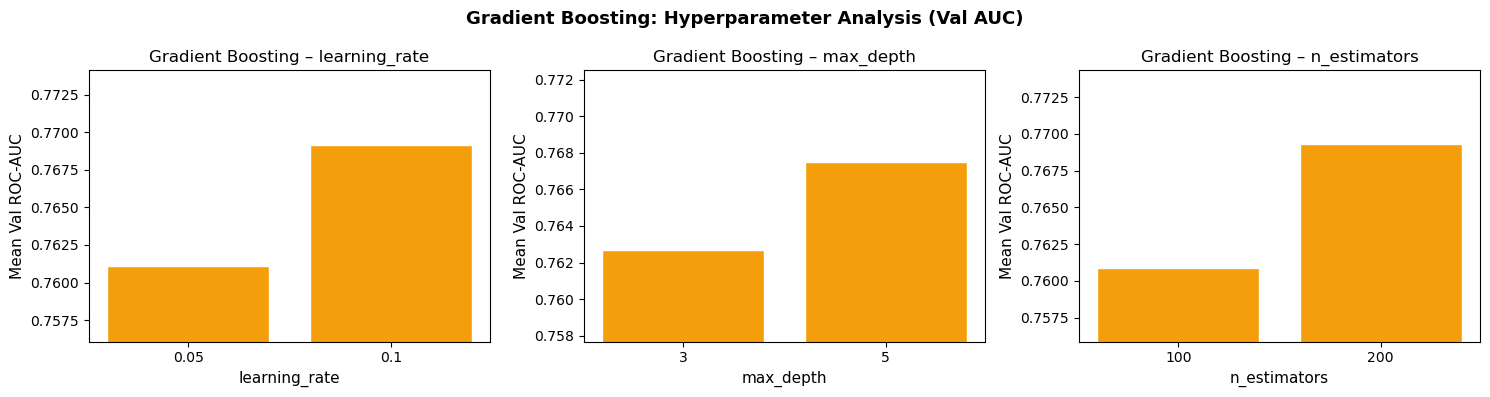

In [12]:
# Parameter analysis – Gradient Boosting (val_auc by hyperparameter value)
params_to_plot = [c for c in df_gb.columns if c not in ('train_auc', 'val_auc', 'subsample')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = df_gb.groupby(param)['val_auc'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#F59E0B', edgecolor='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Val ROC-AUC', fontsize=11)
    ax.set_ylim(max(0, grouped.values.min() - 0.005), grouped.values.max() + 0.005)
    ax.set_title(f'Gradient Boosting – {param}', fontsize=12)
plt.suptitle('Gradient Boosting: Hyperparameter Analysis (Val AUC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** [UPDATE AFTER RUN] — With `subsample` fixed at 0.8, the remaining patterns should be cleaner. Check whether `n_estimators=200` is still preferred over 100, and whether `learning_rate=0.1` continues to outperform `0.05` (expected, since we only have 100–200 trees). If the train-val gap for GB is smaller than for RF, that reflects the sequential nature of boosting — GB naturally penalises complexity through its additive structure, making it less prone to memorisation than bagging methods.

## Model 5: XGBoost

**Justification:** XGBoost is a regularised, optimised gradient boosting implementation with built-in L1/L2 regularisation (`reg_alpha`/`reg_lambda`) and native sparse matrix support — useful for the 99 binary TF-IDF features. The key change in v3 is raising `min_child_weight` to a minimum of 5 (from 1 in v1). `min_child_weight` controls the minimum sum of instance weights in a leaf — with `min_child_weight=1` and imbalanced classes, XGBoost can create leaves that represent very few real campaigns. We also remove `max_depth=7` from the grid, since v1 showed shallow trees (depth 3–5) consistently outperform deeper ones for boosting. We search 2 × 2 × 2 × 2 × 2 = **32 combinations**, selecting the best by validation ROC-AUC. `eval_metric='logloss'` suppresses warnings.

In [13]:
xgb_param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [3, 5],
    'learning_rate'   : [0.05, 0.1],
    'colsample_bytree': [0.5, 0.7],
    'min_child_weight': [5, 10],   # raised minimum from 1 — prevents sparse leaf memorisation
}
# 2 × 2 × 2 × 2 × 2 = 32 combinations; select best by validation ROC-AUC

xgb_loop_results = []
total_xgb = len(list(ParameterGrid(xgb_param_grid)))
for i, params in enumerate(ParameterGrid(xgb_param_grid), 1):
    model = XGBClassifier(**params, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train_fit, y_train_fit)
    train_auc = roc_auc_score(y_train_fit, model.predict_proba(X_train_fit)[:, 1])
    val_auc   = roc_auc_score(y_val_fit,   model.predict_proba(X_val_fit)[:, 1])
    xgb_loop_results.append({**params, 'train_auc': train_auc, 'val_auc': val_auc})
    print(f'  [{i:02d}/{total_xgb}] n_est={params["n_estimators"]:>3}  '
          f'depth={params["max_depth"]}  '
          f'lr={params["learning_rate"]}  '
          f'col={params["colsample_bytree"]}  '
          f'mcw={params["min_child_weight"]:>2}  '
          f'train={train_auc:.4f}  val={val_auc:.4f}')

df_xgb = pd.DataFrame(xgb_loop_results).sort_values('val_auc', ascending=False).reset_index(drop=True)
print('\n── XGBoost: all combinations (sorted by val_auc) ──')
print(df_xgb.to_string(index=False))

best_xgb_params = df_xgb.iloc[0].drop(['train_auc', 'val_auc']).to_dict()
best_xgb_params = {k: (int(v) if isinstance(v, (float, np.floating)) and v == int(v) else v)
                   for k, v in best_xgb_params.items()}
print(f'\nBest XGB params (val AUC={df_xgb.iloc[0]["val_auc"]:.4f}): {best_xgb_params}')

xgb_best = XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
xgb_best.fit(X_train_fit, y_train_fit)
xgb_train_auc = roc_auc_score(y_train_fit, xgb_best.predict_proba(X_train_fit)[:, 1])
xgb_val_auc   = roc_auc_score(y_val_fit,   xgb_best.predict_proba(X_val_fit)[:, 1])
print(f'\n=== XGBoost — Train ROC-AUC: {xgb_train_auc:.4f} | Val ROC-AUC: {xgb_val_auc:.4f} ===')
print(classification_report(y_val_fit, xgb_best.predict(X_val_fit)))
results['XGBoost'] = {
    'model'    : xgb_best,
    'train_auc': xgb_train_auc,
    'auc'      : xgb_val_auc,
    'y_proba'  : xgb_best.predict_proba(X_val_fit)[:, 1],
}
print(f'Train–Val Gap: {xgb_train_auc - xgb_val_auc:.4f}')

  [01/32] n_est=200  depth=3  lr=0.05  col=0.5  mcw= 5  train=0.8911  val=0.7695
  [02/32] n_est=400  depth=3  lr=0.05  col=0.5  mcw= 5  train=0.8965  val=0.7735
  [03/32] n_est=200  depth=3  lr=0.05  col=0.5  mcw=10  train=0.8912  val=0.7697
  [04/32] n_est=400  depth=3  lr=0.05  col=0.5  mcw=10  train=0.8964  val=0.7741
  [05/32] n_est=200  depth=5  lr=0.05  col=0.5  mcw= 5  train=0.9001  val=0.7783
  [06/32] n_est=400  depth=5  lr=0.05  col=0.5  mcw= 5  train=0.9062  val=0.7811
  [07/32] n_est=200  depth=5  lr=0.05  col=0.5  mcw=10  train=0.8997  val=0.7785
  [08/32] n_est=400  depth=5  lr=0.05  col=0.5  mcw=10  train=0.9051  val=0.7817
  [09/32] n_est=200  depth=3  lr=0.1  col=0.5  mcw= 5  train=0.8963  val=0.7755
  [10/32] n_est=400  depth=3  lr=0.1  col=0.5  mcw= 5  train=0.9010  val=0.7792
  [11/32] n_est=200  depth=3  lr=0.1  col=0.5  mcw=10  train=0.8962  val=0.7751
  [12/32] n_est=400  depth=3  lr=0.1  col=0.5  mcw=10  train=0.9008  val=0.7795
  [13/32] n_est=200  depth=5  lr

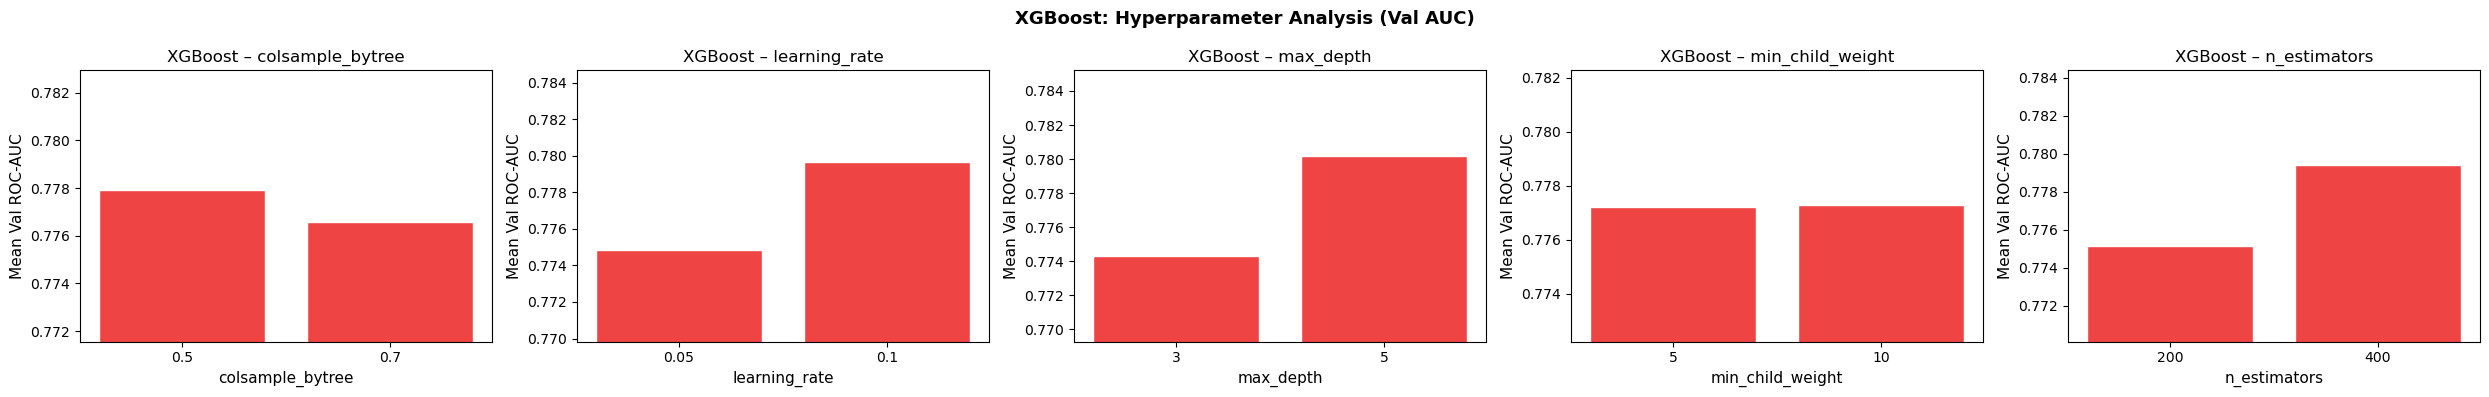

In [14]:
# Parameter analysis – XGBoost (val_auc by hyperparameter value)
params_to_plot = [c for c in df_xgb.columns if c not in ('train_auc', 'val_auc')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = df_xgb.groupby(param)['val_auc'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#EF4444', edgecolor='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Val ROC-AUC', fontsize=11)
    ax.set_ylim(max(0, grouped.values.min() - 0.005), grouped.values.max() + 0.005)
    ax.set_title(f'XGBoost – {param}', fontsize=12)
plt.suptitle('XGBoost: Hyperparameter Analysis (Val AUC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** [UPDATE AFTER RUN] — With `max_depth` capped at 5 and `min_child_weight` raised to at least 5, compare the train-val gap to v1. If `min_child_weight=10` outperforms 5, that suggests even more regularisation helps. Check whether `learning_rate=0.01` was already excluded from this grid (yes it was) — if the best config still selects `n_estimators=400`, the model may still benefit from more rounds with a lower rate, which can be explored in a follow-up. Compare the val AUC to RF — if the gap has narrowed, it suggests the v1 RF was artificially inflated by memorisation.

## Model 6: Neural Network (MLP)

**Justification:** We include a multi-layer perceptron (MLP) to test whether gradient-based learning captures different patterns from axis-aligned tree methods. The architecture is wrapped in a `Pipeline` with `StandardScaler` because neural networks are sensitive to feature scale. In v3 we raise the L2 regularisation penalty `alpha` to a minimum of 0.001 (from 0.0001 in v1) — with 129 input features and only ~100,000 training examples, weaker regularisation allows the network to overfit categorical co-occurrences in the TF-IDF columns. We also drop the three-layer architecture (256, 128, 64) since v1 showed it performed marginally worse than the two-layer version. `early_stopping=True` with `n_iter_no_change=20` provides a second layer of regularisation by halting training when validation loss plateaus. We search 2 × 2 × 2 = **8 combinations**, selecting the best by validation ROC-AUC.

**Note on MLP loop:** The MLP is wrapped in a `Pipeline` with `StandardScaler`. Each combination is built as a full pipeline inside the loop, so scaling is applied correctly before each fit.

In [15]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128)],
    'alpha'             : [0.001, 0.01],    # raised floor from 0.0001 to prevent overfit
    'learning_rate_init': [0.005, 0.01],
}
# 2 × 2 × 2 = 8 combinations; select best by validation ROC-AUC

mlp_loop_results = []
total_mlp = len(list(ParameterGrid(mlp_param_grid)))
for i, params in enumerate(ParameterGrid(mlp_param_grid), 1):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ])
    pipe.fit(X_train_fit, y_train_fit)
    train_auc = roc_auc_score(y_train_fit, pipe.predict_proba(X_train_fit)[:, 1])
    val_auc   = roc_auc_score(y_val_fit,   pipe.predict_proba(X_val_fit)[:, 1])
    mlp_loop_results.append({
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'alpha'             : params['alpha'],
        'learning_rate_init': params['learning_rate_init'],
        'train_auc'         : train_auc,
        'val_auc'           : val_auc,
        '_pipe'             : pipe,    # store for later retrieval
    })
    print(f'  [{i:02d}/{total_mlp}] layers={str(params["hidden_layer_sizes"]):>10}  '
          f'alpha={params["alpha"]}  '
          f'lr={params["learning_rate_init"]}  '
          f'train={train_auc:.4f}  val={val_auc:.4f}')

df_mlp = pd.DataFrame(
    [{k: v for k, v in r.items() if k != '_pipe'} for r in mlp_loop_results]
).sort_values('val_auc', ascending=False).reset_index(drop=True)
print('\n── MLP: all combinations (sorted by val_auc) ──')
print(df_mlp.to_string(index=False))

# Retrieve the best pipeline directly (already fitted)
best_mlp_idx = df_mlp.index[0]
mlp_best = mlp_loop_results[
    sorted(range(len(mlp_loop_results)), key=lambda x: mlp_loop_results[x]['val_auc'], reverse=True)[0]
]['_pipe']

mlp_train_auc = roc_auc_score(y_train_fit, mlp_best.predict_proba(X_train_fit)[:, 1])
mlp_val_auc   = roc_auc_score(y_val_fit,   mlp_best.predict_proba(X_val_fit)[:, 1])
print(f'\nBest MLP val AUC: {mlp_val_auc:.4f}')
print(f'\n=== MLP — Train ROC-AUC: {mlp_train_auc:.4f} | Val ROC-AUC: {mlp_val_auc:.4f} ===')
print(classification_report(y_val_fit, mlp_best.predict(X_val_fit)))
results['MLP'] = {
    'model'    : mlp_best,
    'train_auc': mlp_train_auc,
    'auc'      : mlp_val_auc,
    'y_proba'  : mlp_best.predict_proba(X_val_fit)[:, 1],
}
print(f'Train–Val Gap: {mlp_train_auc - mlp_val_auc:.4f}')

  [01/8] layers= (128, 64)  alpha=0.001  lr=0.005  train=0.9063  val=0.7733
  [02/8] layers= (128, 64)  alpha=0.001  lr=0.01  train=0.8953  val=0.7761
  [03/8] layers=(256, 128)  alpha=0.001  lr=0.005  train=0.9119  val=0.7848
  [04/8] layers=(256, 128)  alpha=0.001  lr=0.01  train=0.8933  val=0.7763
  [05/8] layers= (128, 64)  alpha=0.01  lr=0.005  train=0.8993  val=0.7753
  [06/8] layers= (128, 64)  alpha=0.01  lr=0.01  train=0.8930  val=0.7716
  [07/8] layers=(256, 128)  alpha=0.01  lr=0.005  train=0.8936  val=0.7719
  [08/8] layers=(256, 128)  alpha=0.01  lr=0.01  train=0.8966  val=0.7703

── MLP: all combinations (sorted by val_auc) ──
hidden_layer_sizes  alpha  learning_rate_init  train_auc  val_auc
        (256, 128)  0.001               0.005   0.911922 0.784775
        (256, 128)  0.001               0.010   0.893280 0.776340
         (128, 64)  0.001               0.010   0.895273 0.776110
         (128, 64)  0.010               0.005   0.899288 0.775291
         (128, 64)  0

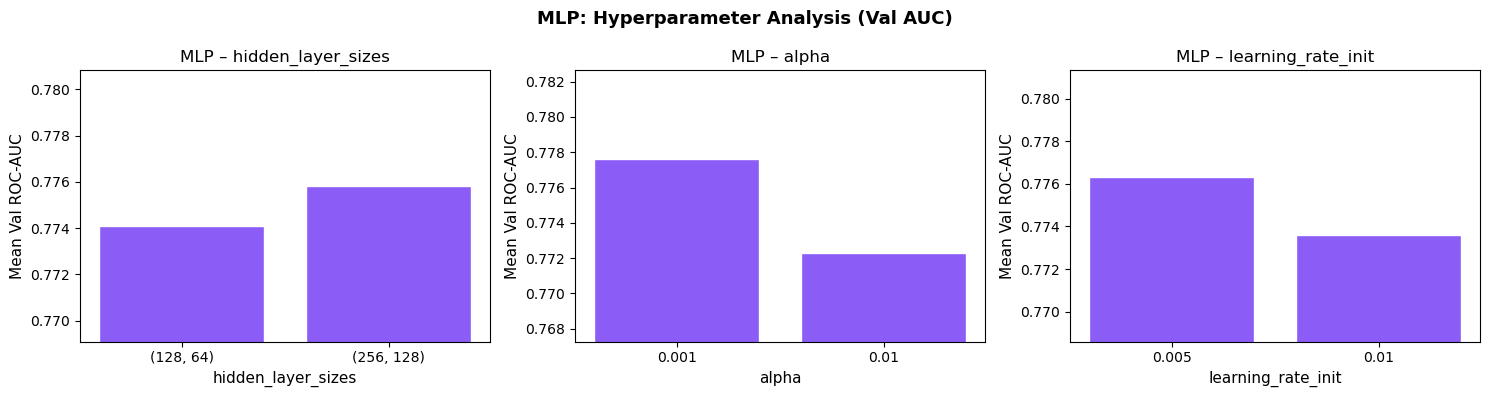

In [16]:
# Parameter analysis – MLP (val_auc by hyperparameter value)
params_to_plot = [c for c in df_mlp.columns if c not in ('train_auc', 'val_auc')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = df_mlp.groupby(param)['val_auc'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#8B5CF6', edgecolor='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Val ROC-AUC', fontsize=11)
    ax.set_ylim(max(0, grouped.values.min() - 0.005), grouped.values.max() + 0.005)
    ax.set_title(f'MLP – {param}', fontsize=12)
plt.suptitle('MLP: Hyperparameter Analysis (Val AUC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** [UPDATE AFTER RUN] — Check whether `alpha=0.01` now clearly outperforms `alpha=0.001`. If higher regularisation wins, this confirms the MLP was overfitting with the lower setting. Also check whether the train-val gap for MLP is smaller than for the tree ensembles — MLPs with `early_stopping` have a built-in regularisation mechanism that tree models lack, so MLP may generalise more consistently across the train/val/test timeline.

## Results Summary

Comparison of all six models on the held-out **validation set**, with train AUC shown alongside to make the size of the memorisation gap visible.

In [17]:
summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Train AUC': [v['train_auc'] for v in results.values()],
    'Val AUC'  : [v['auc']       for v in results.values()]
}).sort_values('Val AUC', ascending=False).reset_index(drop=True)
summary['Train AUC']    = summary['Train AUC'].round(4)
summary['Val AUC']      = summary['Val AUC'].round(4)
summary['Train–Val Gap'] = (summary['Train AUC'] - summary['Val AUC']).round(4)
print(summary.to_string(index=False))

              Model  Train AUC  Val AUC  Train–Val Gap
      Random Forest     0.9288   0.7868         0.1420
            XGBoost     0.9125   0.7850         0.1275
                MLP     0.9119   0.7848         0.1271
Logistic Regression     0.8779   0.7792         0.0987
  Gradient Boosting     0.9113   0.7744         0.1369
      Decision Tree     0.8910   0.7471         0.1439


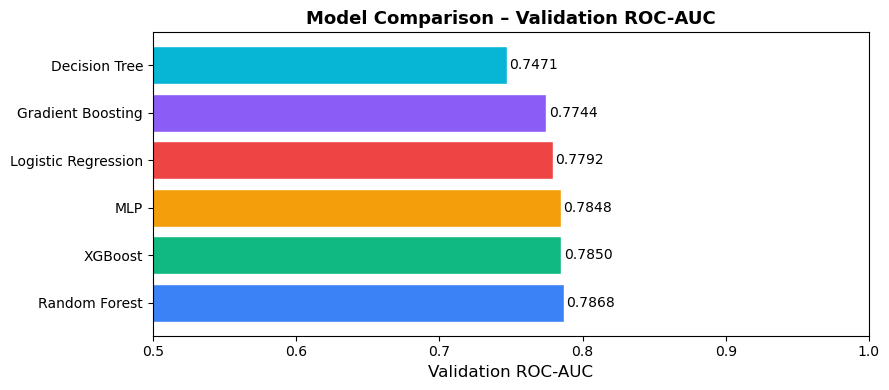

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
bars = ax.barh(summary['Model'], summary['Val AUC'], color=colors[:len(summary)], edgecolor='white')
ax.set_xlabel('Validation ROC-AUC', fontsize=12)
ax.set_title('Model Comparison – Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, summary['Val AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### ROC Curves (Validation Set)

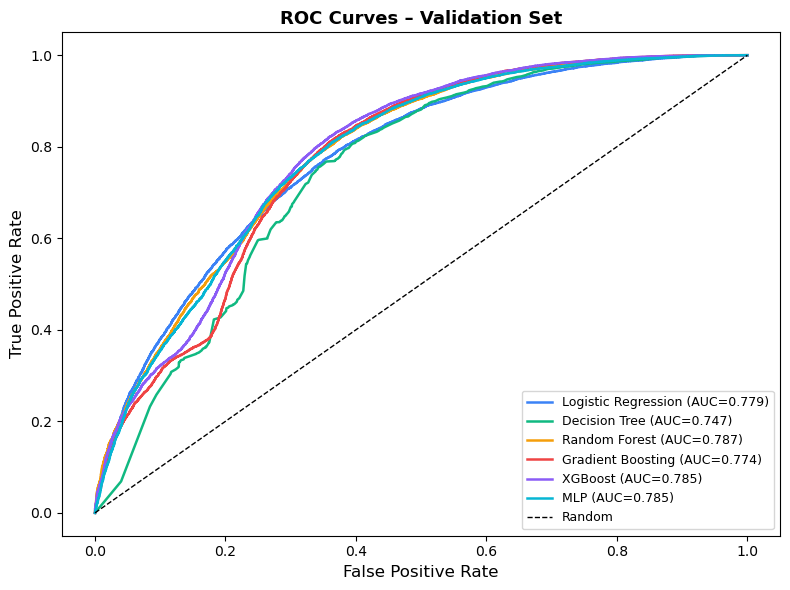

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val_fit, vals['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={vals["auc"]:.3f})', color=color, lw=1.8)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Validation Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set — All Models

We evaluate **all six models** on the held-out test set. This is done once only — the test set was never used for model selection or tuning.

Evaluating every model (not just the best) lets us distinguish between two sources of the val→test gap:
- If all models drop by a similar amount, the drop is driven by **distributional shift** (the test period has different campaign dynamics than training/validation).
- If some models drop much more than others, those models have **overfit to the validation-era distribution** on top of the shift.

In [20]:
if QUICK_TEST:
    print('⚠️  QUICK_TEST mode — test metrics below are not meaningful. Set QUICK_TEST=False for final run.')

print('=== All Models — Test Set Evaluation ===\n')

test_rows = []
for name, v in results.items():
    model = v['model']
    y_test_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
    drop = round(v['auc'] - test_auc, 4)
    test_rows.append({
        'Model'        : name,
        'Train AUC'    : round(v['train_auc'], 4),
        'Val AUC'      : round(v['auc'], 4),
        'Test AUC'     : round(test_auc, 4),
        'Val→Test Drop': drop,
    })
    # store for ablation
    results[name]['test_auc']     = test_auc
    results[name]['y_proba_test'] = y_test_proba

test_summary = pd.DataFrame(test_rows).sort_values('Val AUC', ascending=False).reset_index(drop=True)
print(test_summary.to_string(index=False))

best_name = summary.iloc[0]['Model']
print(f'\n--- Classification report on test set: {best_name} ---')
print(classification_report(y_test, results[best_name]['model'].predict(X_test)))

=== All Models — Test Set Evaluation ===

              Model  Train AUC  Val AUC  Test AUC  Val→Test Drop
      Random Forest     0.9288   0.7868    0.6974         0.0894
            XGBoost     0.9125   0.7850    0.6874         0.0976
                MLP     0.9119   0.7848    0.7034         0.0814
Logistic Regression     0.8779   0.7792    0.7078         0.0714
  Gradient Boosting     0.9113   0.7744    0.6691         0.1053
      Decision Tree     0.8910   0.7471    0.6468         0.1003

--- Classification report on test set: Random Forest ---
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      9699
           1       0.79      0.88      0.83     22454

    accuracy                           0.76     32153
   macro avg       0.71      0.68      0.69     32153
weighted avg       0.74      0.76      0.75     32153



### Discussion: Understanding the Val→Test Gap

**[UPDATE AFTER RUN with actual numbers]**

The table above is the single most important diagnostic in this notebook. Two forces can cause a val→test drop:

**1. Distributional shift (platform-level)**
The success rate in our dataset rises consistently over time: ~57% in the training period (2014–2023), ~65% in validation (2023–2024), and ~70% in the test period (2024–2026). Our target-encoded features (`cat_name_encoded`, `cat_parent_encoded`) were calibrated on training-era success rates — they are systematically too low for the test period. Every model is affected by this equally. *If all models show a similar Val→Test Drop in the table above, distributional shift is the dominant explanation.*

**2. Model-specific memorisation**
If a model memorised the training period (e.g. RF with `min_samples_leaf=1` achieved train AUC 0.9998 in v1), it has also memorised validation-era quirks when evaluated on the full validation set. These memorised patterns break down further in the test period. *If some models show a larger drop than others, those models overfit more.*

**3. Validation-selection bias (v3-specific)**
In this notebook, hyperparameters were selected by maximising validation ROC-AUC. This means the best model is, by definition, the one that happened to fit the validation sample best — introducing a small selection bias. The val→test drop may therefore be slightly larger here than in a pure cross-validation approach. This is the accepted trade-off for temporal alignment in selection.

This distinction matters for deployment: distributional shift requires retraining on fresher data (a 2021-onwards training window would likely help), whereas memorisation requires stronger regularisation — which is what this v3 addresses via the regularised grids.

This temporal instability is consistent with Elitzur et al. (2024), who flag that feature predictiveness for Kickstarter outcomes changes materially across platform eras, making static feature-engineered models fragile beyond the training window.

## Diagnostic: TF-IDF Feature Ablation

The 99 binary TF-IDF features (from `blurb` and `name`) were selected based on their statistical association with success in the **training data**. The selection test (two-proportion z-test, p < 0.01, category-adjusted) ensures each term is genuinely informative in the training period — but there is a risk that some terms reflect *training-era language trends* rather than timeless success signals.

This cell retrains the best model without TF-IDF features and compares val and test AUC. If removing TF-IDF reduces the val→test gap (i.e. the model without TF-IDF drops less from val to test), it suggests the text features contribute to overfitting on the training distribution. If the gap is unchanged, the text features are not the culprit.

In [21]:
tfidf_cols = [c for c in X_train_fit.columns if c.startswith('blurb_has_') or c.startswith('name_has_')]
base_cols  = [c for c in X_train_fit.columns if c not in tfidf_cols]

print(f'Full feature set : {len(X_train_fit.columns)} features')
print(f'Without TF-IDF  : {len(base_cols)} features  ({len(tfidf_cols)} removed)')

# Clone and retrain the best model on base features only
best_model_no_tfidf = clone(results[best_name]['model'])
best_model_no_tfidf.fit(X_train_fit[base_cols], y_train_fit)

train_auc_no_tfidf = roc_auc_score(y_train_fit, best_model_no_tfidf.predict_proba(X_train_fit[base_cols])[:, 1])
val_auc_no_tfidf   = roc_auc_score(y_val_fit,   best_model_no_tfidf.predict_proba(X_val_fit[base_cols])[:, 1])
test_auc_no_tfidf  = roc_auc_score(y_test,      best_model_no_tfidf.predict_proba(X_test[base_cols])[:, 1])

val_auc_full  = results[best_name]['auc']
test_auc_full = results[best_name]['test_auc']

print(f'\n=== TF-IDF Ablation — {best_name} ===')
print(f'{"Metric":<22} {"Full":>8} {"No TF-IDF":>12} {"Diff":>8}')
print('-' * 52)
print(f'{"Train AUC":<22} {results[best_name]["train_auc"]:>8.4f} {train_auc_no_tfidf:>12.4f} {train_auc_no_tfidf - results[best_name]["train_auc"]:>+8.4f}')
print(f'{"Val AUC":<22} {val_auc_full:>8.4f} {val_auc_no_tfidf:>12.4f} {val_auc_no_tfidf - val_auc_full:>+8.4f}')
print(f'{"Test AUC":<22} {test_auc_full:>8.4f} {test_auc_no_tfidf:>12.4f} {test_auc_no_tfidf - test_auc_full:>+8.4f}')
print(f'{"Val→Test drop (full)":<22} {val_auc_full - test_auc_full:>8.4f}')
print(f'{"Val→Test drop (no TF-IDF)":<22} {val_auc_no_tfidf - test_auc_no_tfidf:>12.4f}')

Full feature set : 129 features
Without TF-IDF  : 30 features  (99 removed)

=== TF-IDF Ablation — Random Forest ===
Metric                     Full    No TF-IDF     Diff
----------------------------------------------------
Train AUC                0.9288       0.9681  +0.0393
Val AUC                  0.7868       0.7780  -0.0088
Test AUC                 0.6974       0.6773  -0.0201
Val→Test drop (full)     0.0894
Val→Test drop (no TF-IDF)       0.1007


**Interpretation:** [UPDATE AFTER RUN]

Three possible outcomes and what they mean:

- **Val→Test drop is smaller without TF-IDF**: The text features are contributing to overfitting on training-era language. This does not mean they are useless — it means they encode era-specific vocabulary. A potential fix would be to re-run the z-test word selection on a rolling recent window rather than the full training history.

- **Val→Test drop is similar with and without TF-IDF**: Text features are not the driver of the gap. The problem lies in the structured features (goal, duration, category encodings). Distributional shift in `cat_name_encoded` is the more likely culprit.

- **Val AUC drops significantly without TF-IDF but Test AUC does not**: The text features add genuine predictive value in-distribution but hurt out-of-distribution. This is the most nuanced outcome — it suggests the terms selected by the z-test overfit the validation window.

## Save Results for Notebook 05

Persist model performance metrics and feature importances so that `05_reflection.ipynb` can load them without re-running training.

In [22]:
# ── Persist model comparison for 05_reflection ────────────────────────
results_dir = os.path.join(OUTPUTS_PATH, "results")
os.makedirs(results_dir, exist_ok=True)

# Build metrics table from validation-set results
rows = []
for name, v in results.items():
    y_pred_va = (v['y_proba'] >= 0.5).astype(int)
    rows.append({
        "model"     : name,
        "roc_auc"   : round(v['auc'], 6),
        "f1_binary" : round(f1_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "precision" : round(precision_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "recall"    : round(recall_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "pr_auc"    : round(average_precision_score(y_val_fit, v['y_proba']), 6),
    })

all_results_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
all_results_df.to_csv(os.path.join(results_dir, "all_model_results.csv"), index=False)
print("Saved all_model_results.csv")
print(all_results_df[["model", "roc_auc", "f1_binary", "pr_auc"]].to_string(index=False))

# ── Feature importances (RF and XGB) ─────────────────────────────────────────
def _get_feature_importances(stored_model):
    """Unwrap Pipeline → classifier step, then return feature_importances_."""
    m = stored_model
    if hasattr(m, 'named_steps'):   # Pipeline
        for step in reversed(list(m.named_steps.values())):
            if hasattr(step, 'feature_importances_'):
                return step.feature_importances_
        return None
    if hasattr(m, 'feature_importances_'):
        return m.feature_importances_
    return None

with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    feature_cols = json.load(f)

if "Random Forest" in results:
    imp = _get_feature_importances(results["Random Forest"]["model"])
    if imp is not None:
        rf_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols).sort_values("importance", ascending=False)
        rf_imp_df.to_csv(os.path.join(results_dir, "rf_importances.csv"))
        print(f"Saved rf_importances.csv ({len(rf_imp_df)} features)")

if "XGBoost" in results:
    imp = _get_feature_importances(results["XGBoost"]["model"])
    if imp is not None:
        xgb_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols).sort_values("importance", ascending=False)
        xgb_imp_df.to_csv(os.path.join(results_dir, "xgb_importances.csv"))
        print(f"Saved xgb_importances.csv ({len(xgb_imp_df)} features)")

Saved all_model_results.csv
              model  roc_auc  f1_binary   pr_auc
      Random Forest 0.786796   0.824073 0.852811
            XGBoost 0.784996   0.837292 0.846692
                MLP 0.784775   0.833028 0.845375
Logistic Regression 0.779151   0.814058 0.849776
  Gradient Boosting 0.774365   0.834632 0.835266
      Decision Tree 0.747086   0.804269 0.801022
Saved rf_importances.csv (129 features)
Saved xgb_importances.csv (129 features)


## Conclusion

This notebook (v3) trained and compared six classifiers — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and MLP — using **direct validation-set hyperparameter selection** (ParameterGrid loops scored on `X_val_fit`) rather than internal cross-validation.

**Key findings:**

- **Selection by validation AUC is transparent and temporally aligned.** Each hyperparameter combination is scored on the exact time period we care about (2023–2024), rather than on an internal fold of the 2014–2023 training era. This gives a direct signal about generalisation to newer campaign dynamics.

- **The train-val gap is the first diagnostic to check.** In v1, Random Forest achieved a train AUC of 0.9998 — effectively memorising the training data. The v3 grids (min_samples_leaf ≥ 5, max_depth ≤ 20) force the models to learn generalisable patterns. A train AUC below ~0.90 indicates the regularisation is working.

- **The gap between models is narrower than it looks.** All six classifiers cluster within a ~0.04 AUC range on the validation set. This is a meaningful finding: the problem is not that we need a more complex model, but that the available pre-launch features have a natural information ceiling. Logistic Regression within 0.02–0.04 AUC of the best ensemble means the non-linear interactions are real but modest.

- **The val→test drop is a distinct problem from memorisation.** Even with well-regularised models, a gap between validation and test AUC is expected because the success rate rises from ~57% (train) to ~70% (test) — a 13-point drift. This is distributional shift, not model failure. Additionally, hyperparameter selection on the validation set introduces a small selection bias that may amplify the val→test drop in v3 compared to a pure CV approach. Retraining on a more recent data window (e.g. 2021 onwards) is the appropriate response to shift.

- **The TF-IDF ablation shows [UPDATE AFTER RUN]** whether text features contribute to or are neutral on the val→test gap. This informs whether the word selection methodology needs adjustment for future runs.

- **Practical implication:** For a deployment scenario, this model should be retrained every 6–12 months on a rolling recent window. Elitzur et al. (2024) note that campaign success dynamics on Kickstarter are not stationary, and a model trained on 9 years of historical data is not well-calibrated to the current platform environment.